In [2]:
import os
import sys
import datetime
import itertools
import io
import site
try:
	import cv2
except ImportError:
	site.addsitedir('D:\\Program Files\\opencv-4.5.0-dldt-2021.1-vc16-avx2\\opencv\\build\\python')
import cv2
import numpy as np
import scipy
import tensorflow as tf
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard, Callback
from tensorflow.keras.layers import (Conv2D, Dense, Dropout, Flatten,
                                     MaxPooling2D, BatchNormalization,
                                     Activation, Reshape)
# from tensorflow.keras.layers.experimental.preprocessing import Resizing
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras import models, layers, mixed_precision
# from keras_cv.models.legacy.vit import ViTTiny16

INPUT_DATASET = "D:\\Downloads\\nyu_depth_v2_labeled2.mat"
LEARNING_RATE = 0.0001
BATCH_SIZE = 32

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

# def create_alexnet(input_shape, num_classes):
#     print(f'Creating model for {input_shape}, # class={num_classes}')
#     model = Sequential([
#         # Resizing(256, 256, input_shape=input_shape),
#         # Reshape(input_shape+(1,), input_shape=input_shape),

#         Conv2D(96, (11, 11), strides=4, activation='relu',
#         input_shape=input_shape
#         ),
#         BatchNormalization(),
#         Activation('relu'),
#         MaxPooling2D(pool_size=(3, 3), strides=2),

#         Conv2D(256, (5, 5), padding='same', activation='relu'),
#         BatchNormalization(),
#         Activation('relu'),
#         MaxPooling2D(pool_size=(3, 3), strides=2),

#         Conv2D(384, (3, 3), padding='same', activation='relu'),
#         BatchNormalization(),
#         Activation('relu'),

#         Conv2D(384, (3, 3), padding='same', activation='relu'),
#         BatchNormalization(),
#         Activation('relu'),

#         Conv2D(256, (3, 3), padding='same', activation='relu'),
#         BatchNormalization(),
#         Activation('relu'),
#         MaxPooling2D(pool_size=(3, 3), strides=2),

#         Flatten(),

#         Dense(4096, activation='relu'),
#         BatchNormalization(),
#         Activation('relu'),
#         Dropout(0.5),

#         Dense(4096, activation='relu'),
#         BatchNormalization(),
#         Activation('relu'),
#         Dropout(0.5),

#         Dense(num_classes, activation='softmax')
#     ])
#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
#         loss='sparse_categorical_crossentropy',
#         metrics=['accuracy'])
#     model.build(input_shape)

#     return model

# model = create_alexnet((256, 256, 1), 40)

<KeysViewHDF5 ['#refs#', '#subsystem#', 'accelData', 'depths', 'images', 'instances', 'labels', 'names', 'namesToIds', 'rawDepthFilenames', 'rawDepths', 'rawRgbFilenames', 'sceneTypes', 'scenes']>
(1449, 640, 480)


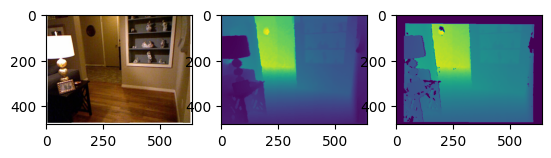

In [12]:
import h5py


f = h5py.File(INPUT_DATASET, 'r')
print(f.keys())
depth_imgs = f['depths']
imgs = f['images']
rawdepth_imgs = f['rawDepths']
print(depth_imgs.shape)
# show all three images as subplots
fig, axs = plt.subplots(1, 3)
idx = 1234
axs[0].imshow(imgs[idx].T)
axs[1].imshow(depth_imgs[idx].T)
axs[2].imshow(rawdepth_imgs[idx].T)
plt.show()

# labelled data from nyu_depth_v2_labeled.mat only have 1449 frames
